# Back Testing

## Fetching data

In [1]:
%run data.ipynb

In [2]:
from datetime import date

In [3]:
test = NepseData('NEPSE', '2016-06-19', str(date.today()), 'NRS', '1D')

In [4]:
test.dump_data()

Data fetched.
Data converted from json to csv.


## Data structuring

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ta.utils import dropna

In [6]:
def plot_OHLC(data, ticker, window):
    plt.figure(figsize=(15,5))
    plt.title('{} price data in {} timeframe'.format(ticker, window))
    plt.plot(data['Close'])
    plt.show()

In [7]:
daily_df = pd.read_csv('data.csv')
daily_df = dropna(daily_df)
daily_df['Timestamp'] = pd.to_datetime(daily_df['Timestamp'])
daily_df = daily_df.set_index('Timestamp')

In [8]:
daily_df.tail()

,Open,High,Low,Close,Volume
Timestamp,,,,,
2024-01-21 14:59:59,2156.52,2165.67,2123.86,2130.18,7.677740e+09
2024-01-22 14:59:59,2128.56,2134.81,2090.64,2098.69,6.366070e+09
2024-01-23 14:59:59,2096.99,2112.15,2087.22,2098.29,4.294567e+09
2024-01-24 14:59:59,2098.97,2120.46,2083.45,2088.04,3.897023e+09
2024-01-25 14:59:59,2088.49,2096.75,2072.78,2084.09,3.764505e+09


### Converting daily data to weekly

In [9]:
weekly_df = daily_df.resample('W-Sat').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
})
weekly_df = dropna(weekly_df)

In [10]:
weekly_df.tail()

,Open,High,Low,Close,Volume
Timestamp,,,,,
2023-12-30,2113.69,2132.63,2055.35,2068.90,1.665145e+10
2024-01-06,2072.45,2096.44,2023.76,2049.28,1.815861e+10
2024-01-13,2049.90,2116.44,2019.77,2088.99,2.547756e+10
2024-01-20,2093.48,2215.54,2093.44,2155.82,3.141824e+10
2024-01-27,2156.52,2165.67,2072.78,2084.09,2.599990e+10


### Converting daily data to monthly

In [11]:
monthly_df = daily_df.resample('M').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
})
monthly_df = dropna(monthly_df)

In [12]:
monthly_df.tail()

,Open,High,Low,Close,Volume
Timestamp,,,,,
2023-09-30,1990.82,2040.28,1929.66,2004.30,2.462483e+10
2023-10-31,2004.58,2005.32,1846.79,1864.40,2.028302e+10
2023-11-30,1864.19,1926.52,1816.40,1858.53,1.940002e+10
2023-12-31,1858.47,2154.51,1830.31,2068.90,7.228835e+10
2024-01-31,2072.45,2215.54,2019.77,2084.09,1.010543e+11


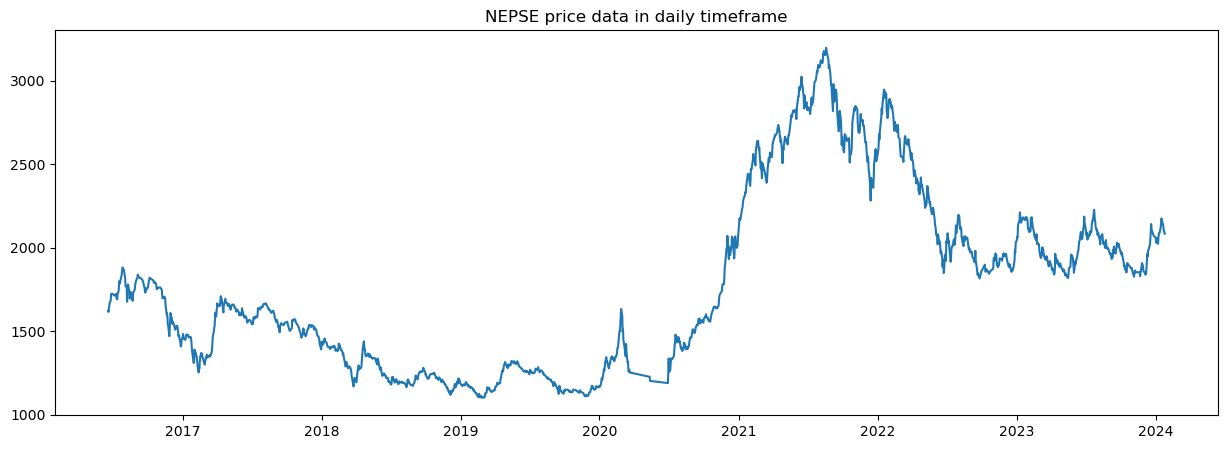

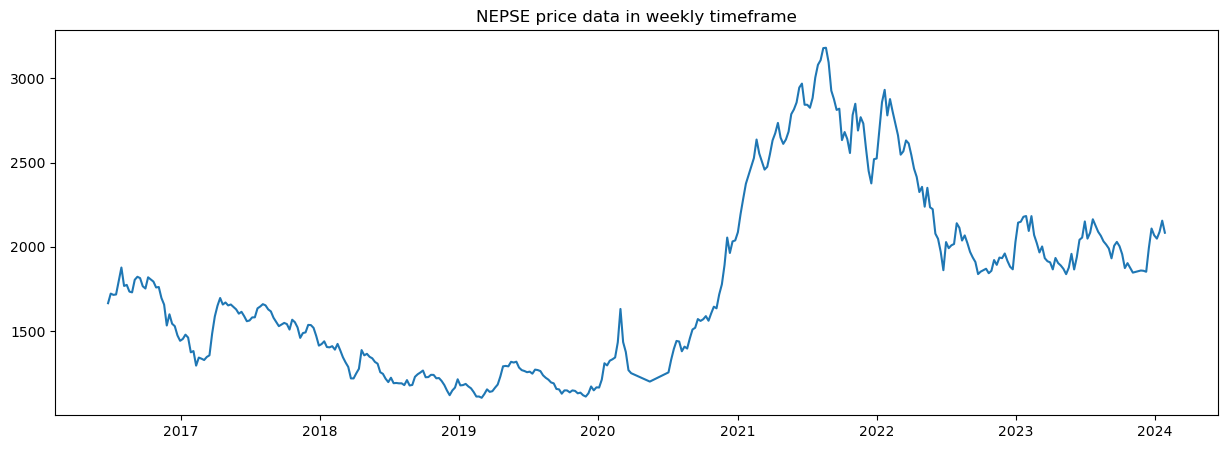

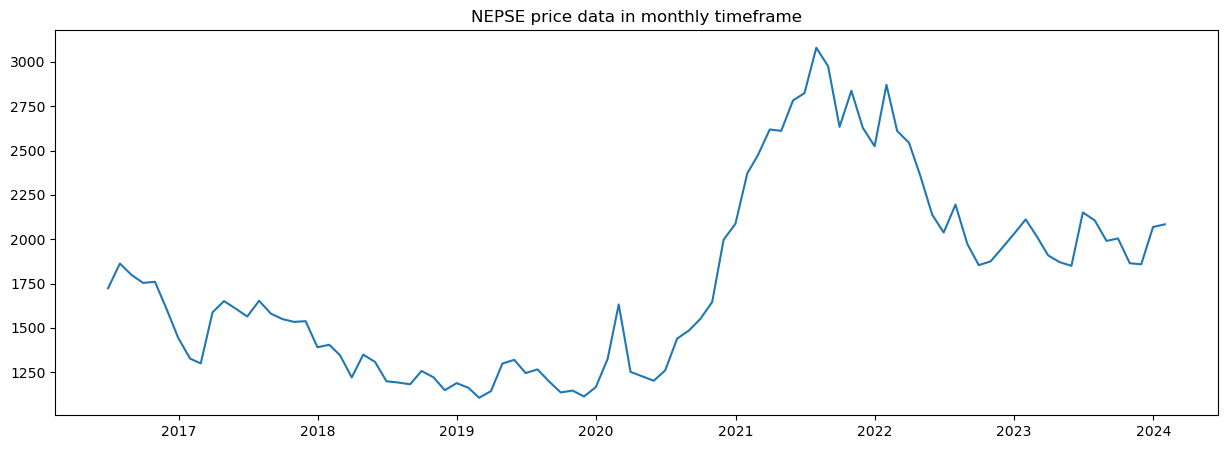

In [13]:
plot_OHLC(daily_df, 'NEPSE', 'daily')
plot_OHLC(weekly_df, 'NEPSE', 'weekly')
plot_OHLC(monthly_df, 'NEPSE', 'monthly')

## Core algorithm

### RSI

In [14]:
from ta.momentum import RSIIndicator

daily_df['RSI'] = RSIIndicator(daily_df['Close'], window=14).rsi()
weekly_df['RSI'] = RSIIndicator(weekly_df['Close'], window=14).rsi()
monthly_df['RSI'] = RSIIndicator(monthly_df['Close'], window=14).rsi()

In [15]:
print(daily_df[['RSI']].tail().to_markdown(), end='\n\n')
print(weekly_df[['RSI']].tail().to_markdown(), end='\n\n')
print(monthly_df[['RSI']].tail().to_markdown(), end='\n\n')

| Timestamp           |     RSI |
|:--------------------|--------:|
| 2024-01-21 14:59:59 | 62.1105 |
| 2024-01-22 14:59:59 | 55.8616 |
| 2024-01-23 14:59:59 | 55.7849 |
| 2024-01-24 14:59:59 | 53.7464 |
| 2024-01-25 14:59:59 | 52.9435 |

| Timestamp           |     RSI |
|:--------------------|--------:|
| 2023-12-30 00:00:00 | 57.5974 |
| 2024-01-06 00:00:00 | 55.8763 |
| 2024-01-13 00:00:00 | 58.5744 |
| 2024-01-20 00:00:00 | 62.7075 |
| 2024-01-27 00:00:00 | 56.2236 |

| Timestamp           |     RSI |
|:--------------------|--------:|
| 2023-09-30 00:00:00 | 47.3929 |
| 2023-10-31 00:00:00 | 43.38   |
| 2023-11-30 00:00:00 | 43.2147 |
| 2023-12-31 00:00:00 | 50.4968 |
| 2024-01-31 00:00:00 | 50.9856 |



<Axes: xlabel='Timestamp'>

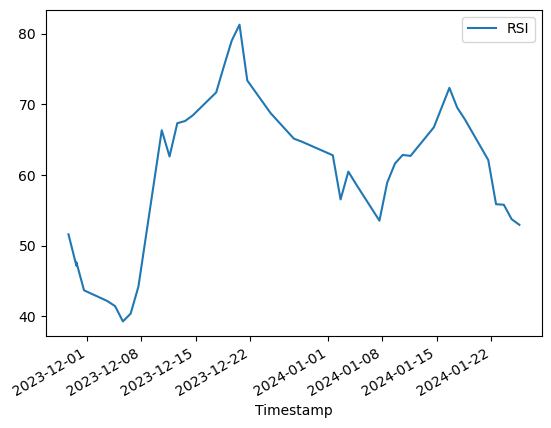

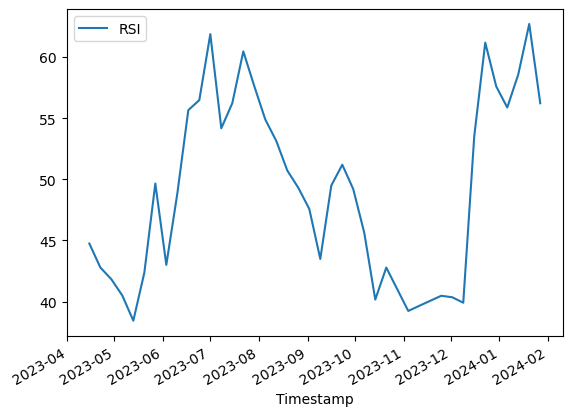

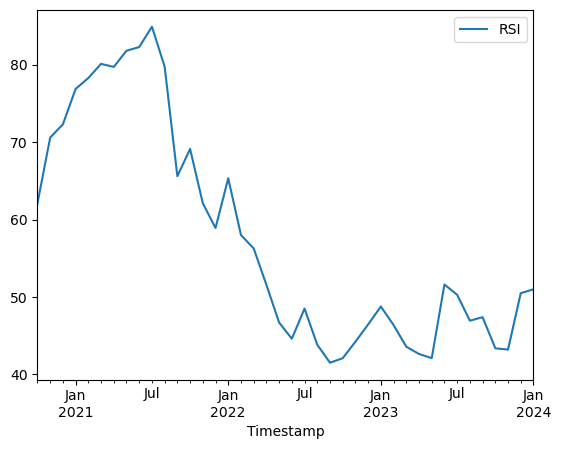

In [16]:
daily_df[['RSI']].tail(40).plot()
weekly_df[['RSI']].tail(40).plot()
monthly_df[['RSI']].tail(40).plot()

In [17]:
from ta.momentum import stochrsi_d, stochrsi_k

# Daily
daily_df['stochrsi_d'] = stochrsi_d(daily_df['Close'], window=14) * 100
daily_df['stochrsi_k'] = stochrsi_k(daily_df['Close'], window=14) * 100

# Weekly
weekly_df['stochrsi_d'] = stochrsi_d(weekly_df['Close'], window=14) * 100
weekly_df['stochrsi_k'] = stochrsi_k(weekly_df['Close'], window=14) * 100

# Monthly
monthly_df['stochrsi_d'] = stochrsi_d(monthly_df['Close'], window=14) * 100
monthly_df['stochrsi_k'] = stochrsi_k(monthly_df['Close'], window=14) * 100

print('Daily stochastic RSI')
print(daily_df[['stochrsi_d', 'stochrsi_k']].tail(10).to_markdown(), end='\n\n')

print('Weekly stochastic RSI')
print(weekly_df[['stochrsi_d', 'stochrsi_k']].tail(10).to_markdown(), end='\n\n')

print('Monthly stochastic RSI')
print(monthly_df[['stochrsi_d', 'stochrsi_k']].tail(10).to_markdown(), end='\n\n')

Daily stochastic RSI
| Timestamp           |   stochrsi_d |   stochrsi_k |
|:--------------------|-------------:|-------------:|
| 2024-01-11 14:59:59 |      25.1631 |     31.9139  |
| 2024-01-14 14:59:59 |      34.5608 |     44.3904  |
| 2024-01-16 14:59:59 |      47.6158 |     66.5432  |
| 2024-01-17 14:59:59 |      64.9508 |     83.9187  |
| 2024-01-18 14:59:59 |      79.1929 |     87.1168  |
| 2024-01-21 14:59:59 |      80.012  |     69.0006  |
| 2024-01-22 14:59:59 |      66.9544 |     44.7457  |
| 2024-01-23 14:59:59 |      45.6964 |     23.343   |
| 2024-01-24 14:59:59 |      25.531  |      8.50423 |
| 2024-01-25 14:59:59 |      12.0735 |      4.37319 |

Weekly stochastic RSI
| Timestamp           |   stochrsi_d |   stochrsi_k |
|:--------------------|-------------:|-------------:|
| 2023-11-25 00:00:00 |      4.45544 |      3.87501 |
| 2023-12-02 00:00:00 |      5.35607 |      6.99997 |
| 2023-12-09 00:00:00 |      6.2871  |      7.98631 |
| 2023-12-16 00:00:00 |     17.7754  |

<Axes: xlabel='Timestamp'>

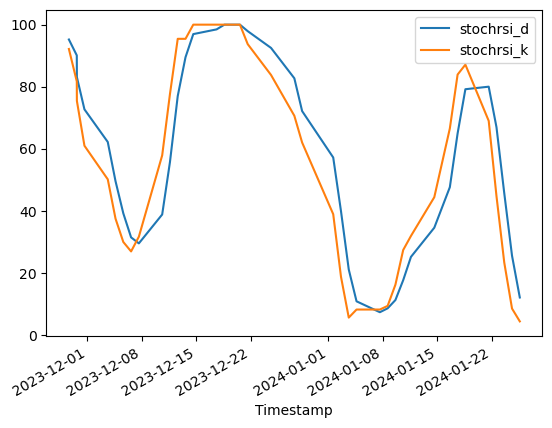

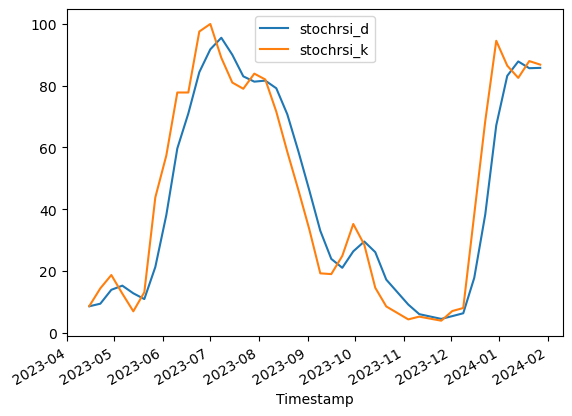

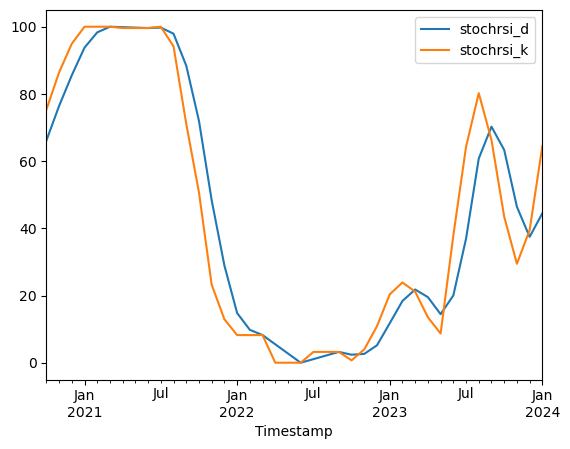

In [18]:
daily_df[['stochrsi_d', 'stochrsi_k']].tail(40).plot()
weekly_df[['stochrsi_d', 'stochrsi_k']].tail(40).plot()
monthly_df[['stochrsi_d', 'stochrsi_k']].tail(40).plot()